# Chapter 2: Hyperbolic Geometry And Its Friends

**Source Span.** Thurston, *Three-Dimensional Geometry and Topology, Volume 1*, Chapter 2, printed pages 43-108. Source orientation covered negatively curved surfaces, the inversive and half-space models, the hyperboloid and Klein models, hyperbolic computations, isometries, complex coordinates, Hermitian forms for `H^3`, and the geometry of the three-sphere.

**Chapter goal.** Turn the chapter into a working model comparison lab. Hyperbolic geometry is not one picture; it is a family of equivalent coordinate systems, each making a different invariant visible. The notebook keeps those invariants explicit: Poincare geodesics meet the boundary orthogonally, the upper half-plane metric scales like inverse height, the hyperboloid model stores distance in a Minkowski inner product, Klein projection straightens geodesics while distorting angles, and Hopf flows on `S^3` reveal a different homogeneous geometry.

This is original teaching material. It does not reproduce textbook drawings or prose. The visuals are generated from formulas and checked with numerical or symbolic ledgers so the reader can inspect the geometry without the PDF open.


In [1]:
from pathlib import Path
import json, math, sys
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp
from IPython.display import Markdown, display

BOOK_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'source_map.json').exists())
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))
from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_csv, save_json, save_matplotlib, save_plotly_html

UNIT_KEY = 'chapter-02-hyperbolic-geometry-and-its-friends'
UNIT_TITLE = 'Hyperbolic Geometry And Its Friends'
ART_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIG = ART_ROOT / 'figures'; HTML = ART_ROOT / 'html'; CHECK = ART_ROOT / 'checks'; TABLE = ART_ROOT / 'tables'
ARTIFACTS = []
def remember(path):
    ARTIFACTS.append(Path(path)); return Path(path)
plt.rcParams.update({'figure.figsize': (7.4, 5.2), 'axes.spines.top': False, 'axes.spines.right': False})
display(Markdown(f'Writing Chapter 2 artifacts to `{ART_ROOT.relative_to(BOOK_ROOT).as_posix()}`.'))


Writing Chapter 2 artifacts to `artifacts/chapter-02-hyperbolic-geometry-and-its-friends`.

## Visual Storyboard And Library Routing

| Source block | Representation | Library choice | Check |
| --- | --- | --- | --- |
| Negatively curved surfaces | Pseudosphere tractrix surface | Plotly surface for rotatable 3D inspection | meridian radius decreases while intrinsic scale grows |
| Inversive and Poincare models | Disk geodesics plus half-plane scaling | Matplotlib for exact static labels | orthogonal-circle residuals and metric scale ratios |
| Hyperboloid/Klein/Poincare | One point cloud projected three ways | Matplotlib + NumPy | points remain inside model domains and radial order is preserved |
| Hyperbolic computations | Minkowski distance and triangle law | SymPy/NumPy | `cosh d = -<u,v>` and law-of-cosines residuals |
| Isometries, `H^3`, and `S^3` | Hopf-flow stereographic projection | Plotly 3D HTML | fibers stay linked and have finite stereographic coordinates |

**Library Routing.** Plotly is used where rotation changes the learner's understanding: the pseudosphere and Hopf-flow scenes. Matplotlib handles model comparison diagrams because equal aspect and boundary annotations matter. SymPy is used only for exact formula checks; NumPy handles the sample geometry. NetworkX appears once as a dependency graph tying models to invariants.


In [2]:
routing_rows = [
    {'concept': 'pseudosphere and negative curvature', 'library': 'Plotly', 'artifact': 'pseudosphere-negative-curvature.html', 'check': 'tractrix radius ledger'},
    {'concept': 'Poincare disk and inversive geodesics', 'library': 'Matplotlib + NumPy', 'artifact': 'poincare-half-plane-models.png', 'check': 'circle orthogonality residuals'},
    {'concept': 'hyperboloid, Klein, Poincare projections', 'library': 'Matplotlib', 'artifact': 'hyperboloid-klein-poincare-projections.png', 'check': 'domain and radial-order ledger'},
    {'concept': 'distance and triangle computations', 'library': 'SymPy + NumPy', 'artifact': 'hyperbolic-distance-checks.json', 'check': 'Minkowski and law-of-cosines residuals'},
    {'concept': 'Hopf flow on the three-sphere', 'library': 'Plotly', 'artifact': 'hopf-flow-stereographic.html', 'check': 'finite stereographic fibers'},
]
routing_path = remember(save_csv(routing_rows, TABLE / 'hyperbolic-geometry-and-its-friends-routing.csv'))
display_artifact(routing_path)


[hyperbolic-geometry-and-its-friends-routing.csv](D:/Geometry/Three-Dimensional-Geometry-and-Topology/artifacts/chapter-02-hyperbolic-geometry-and-its-friends/tables/hyperbolic-geometry-and-its-friends-routing.csv)

## 1. Negative Curvature Before The Abstract Model

The pseudosphere is a warning and a bridge. It exhibits constant negative curvature locally, yet it develops an edge, so it cannot be the whole hyperbolic plane. That failure is pedagogically useful: it explains why Thurston quickly moves from surfaces embedded in Euclidean space to intrinsic and projective models.

The surface below is a tractrix surface of revolution. The check records how the radius shrinks along the meridian, making the edge visible without relying on a copied drawing.


In [3]:
u = np.linspace(0, 2*np.pi, 80)
v = np.linspace(0.05, 2.6, 80)
U, V = np.meshgrid(u, v)
r = 1 / np.cosh(V)
X = r * np.cos(U); Y = r * np.sin(U); Z = V - np.tanh(V)
fig = go.Figure(data=[go.Surface(x=X, y=Y, z=Z, colorscale='Viridis', showscale=False, opacity=.92)])
fig.update_layout(title='Pseudosphere: local negative curvature with an edge', scene=dict(aspectmode='data'), margin=dict(l=0,r=0,t=40,b=0))
pseudo_html = remember(save_plotly_html(fig, HTML / 'pseudosphere-negative-curvature.html'))
radius_ledger = [{'v': float(vv), 'radius': float(1/np.cosh(vv)), 'height': float(vv - np.tanh(vv))} for vv in np.linspace(.05, 2.6, 8)]
pseudo_json = remember(save_json({'radius_ledger': radius_ledger, 'checks': {'radius_decreases': all(radius_ledger[i]['radius'] > radius_ledger[i+1]['radius'] for i in range(len(radius_ledger)-1))}}, CHECK / 'pseudosphere-negative-curvature.json'))
assert all(radius_ledger[i]['radius'] > radius_ledger[i+1]['radius'] for i in range(len(radius_ledger)-1))
display_artifact(pseudo_html, width=820, height=540)


D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


## 2. Inversive Models: Disk And Half-Plane

The Poincare disk packages hyperbolic lines as Euclidean circles orthogonal to the boundary. The upper half-plane packages the metric as a scale factor: the same Euclidean segment is hyperbolically longer when it is closer to the boundary. Both pictures are conformal, so angles are trustworthy even when Euclidean sizes are not.


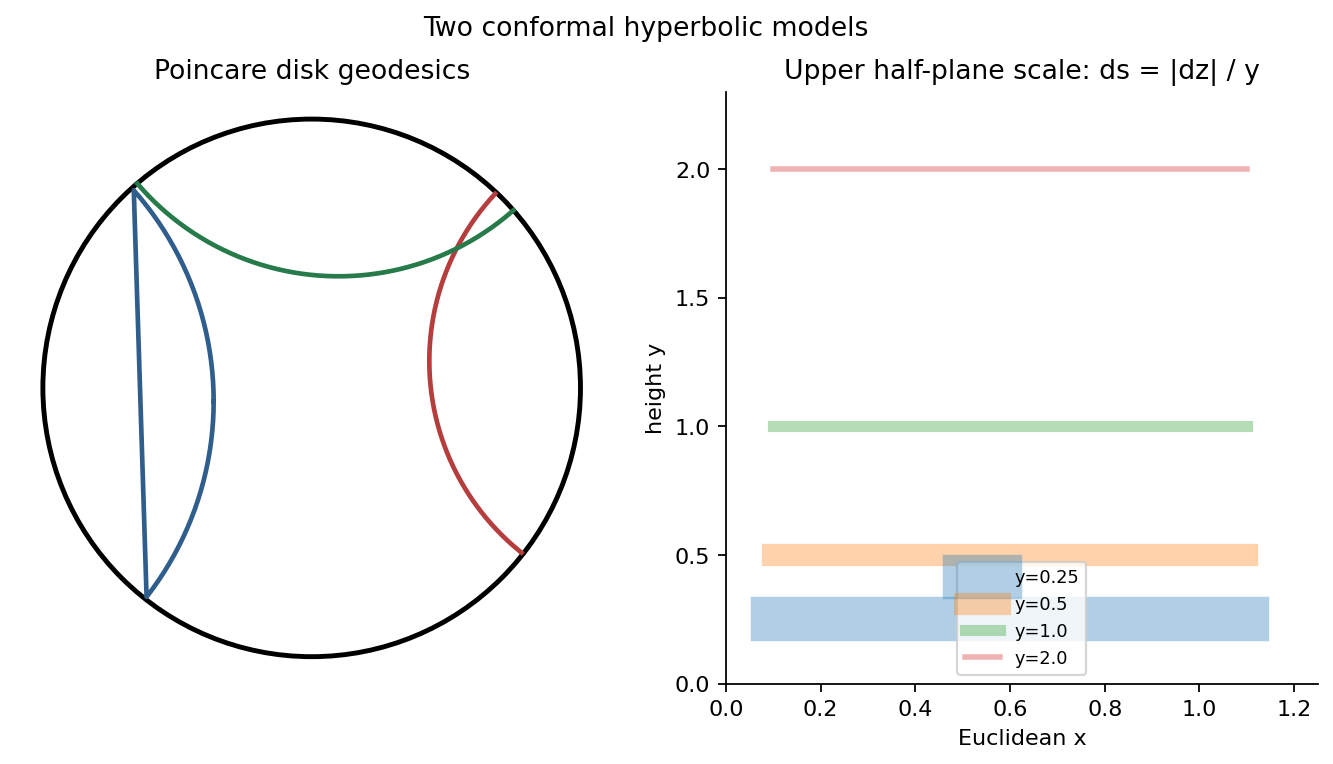

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.8))
ax = axes[0]
ax.add_patch(Circle((0, 0), 1, fill=False, color='black', lw=2.2))
centers = [np.array([1.35, 0.1]), np.array([-1.55, -0.05]), np.array([0.1, 1.4])]
residuals = []
for c, color in zip(centers, ['#b53d3d', '#2f5d8c', '#277a4a']):
    rr = math.sqrt(float(c @ c - 1))
    theta = np.linspace(0, 2*np.pi, 600)
    xy = c[:, None] + rr*np.vstack([np.cos(theta), np.sin(theta)])
    mask = np.sum(xy**2, axis=0) <= 1.0001
    ax.plot(xy[0, mask], xy[1, mask], lw=2.1, color=color)
    residuals.append(abs(float(c @ c - rr*rr - 1)))
ax.set_title('Poincare disk geodesics'); ax.set_aspect('equal'); ax.axis('off')

ax = axes[1]
y_levels = np.array([.25, .5, 1.0, 2.0])
for y0 in y_levels:
    ax.plot([0.1, 1.1], [y0, y0], lw=5/y0, alpha=.35, label=f'y={y0}')
ax.set_xlim(0, 1.25); ax.set_ylim(0, 2.3)
ax.set_xlabel('Euclidean x'); ax.set_ylabel('height y')
ax.set_title('Upper half-plane scale: ds = |dz| / y')
ax.legend(fontsize=8)
fig.suptitle('Two conformal hyperbolic models')
inversive_png = remember(save_matplotlib(fig, FIG / 'poincare-half-plane-models.png'))
plt.close(fig)
scale_ratios = (1 / y_levels).tolist()
inv_json = remember(save_json({'orthogonality_residuals': residuals, 'half_plane_scale_factors': scale_ratios, 'checks': {'disk_geodesics_orthogonal': max(residuals) < 1e-12, 'scale_decreases_with_height': all(scale_ratios[i] > scale_ratios[i+1] for i in range(len(scale_ratios)-1))}}, CHECK / 'poincare-half-plane-models.json'))
assert max(residuals) < 1e-12
display_artifact(inversive_png)


## 3. Hyperboloid, Klein, And Poincare Projections

The hyperboloid model is computationally crisp: distance is encoded by the Minkowski inner product. The Klein model projects from the origin, so geodesics become straight chords but angles are distorted. Poincare projection keeps angles but bends geodesics. The next visual uses one family of hyperboloid points and projects it into both disk models.


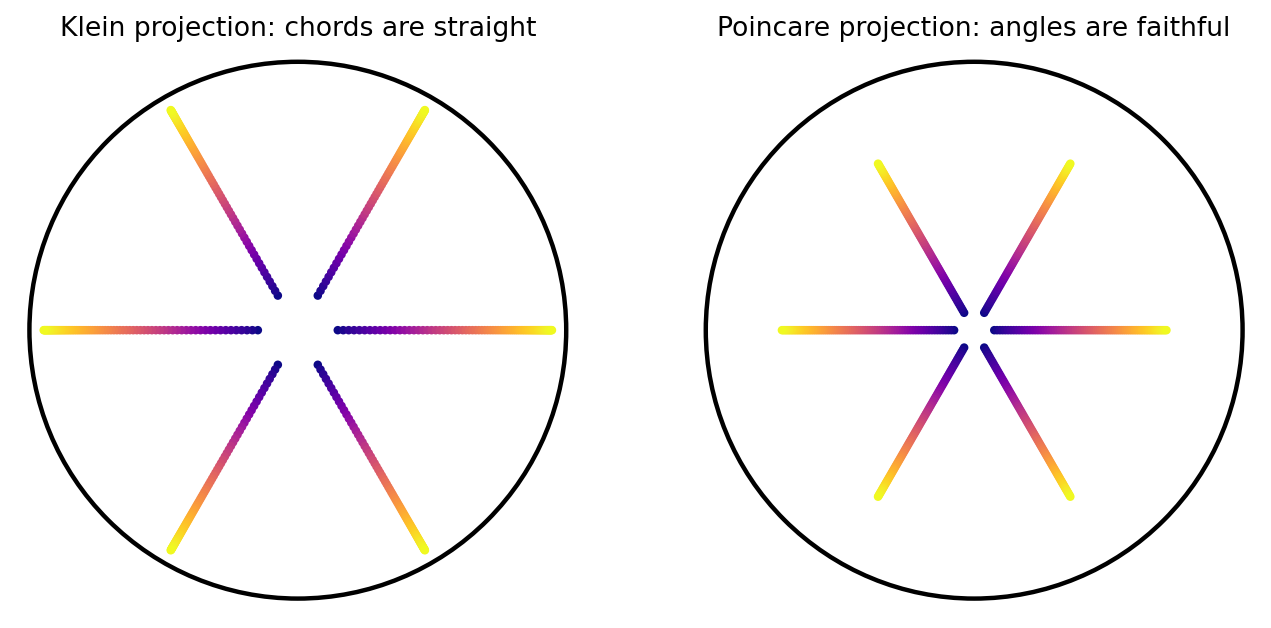

In [5]:
t = np.linspace(0.15, 1.8, 80)
angles = np.linspace(0, 2*np.pi, 6, endpoint=False)
cloud = []
for a in angles:
    for s in t:
        cloud.append([math.cosh(s), math.sinh(s)*math.cos(a), math.sinh(s)*math.sin(a)])
cloud = np.array(cloud)
klein = cloud[:, 1:3] / cloud[:, [0]]
poincare = cloud[:, 1:3] / (cloud[:, [0]] + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.6))
for ax, pts, title in [(axes[0], klein, 'Klein projection: chords are straight'), (axes[1], poincare, 'Poincare projection: angles are faithful')]:
    ax.add_patch(Circle((0, 0), 1, fill=False, lw=2, color='black'))
    ax.scatter(pts[:,0], pts[:,1], s=8, c=np.linalg.norm(pts, axis=1), cmap='plasma')
    ax.set_aspect('equal'); ax.set_xlim(-1.05, 1.05); ax.set_ylim(-1.05, 1.05); ax.set_title(title); ax.axis('off')
projection_png = remember(save_matplotlib(fig, FIG / 'hyperboloid-klein-poincare-projections.png'))
plt.close(fig)
inside_klein = bool(np.all(np.linalg.norm(klein, axis=1) < 1))
inside_poincare = bool(np.all(np.linalg.norm(poincare, axis=1) < 1))
projection_json = remember(save_json({'sample_count': int(len(cloud)), 'inside_klein': inside_klein, 'inside_poincare': inside_poincare, 'max_klein_radius': float(np.linalg.norm(klein, axis=1).max()), 'max_poincare_radius': float(np.linalg.norm(poincare, axis=1).max())}, CHECK / 'hyperboloid-projection-checks.json'))
assert inside_klein and inside_poincare
display_artifact(projection_png)


## 4. Hyperbolic Computations As Invariant Checks

Model changes become safe only when the invariant formulas agree. In the hyperboloid model, points satisfy `-x0^2 + x1^2 + x2^2 = -1`, and the distance between future-pointing unit timelike vectors is recovered from `cosh d = -<u,v>`. The same cell checks a hyperbolic triangle law of cosines numerically.


In [6]:
def minkowski(u, v):
    return -u[0]*v[0] + np.dot(u[1:], v[1:])
A = np.array([1.0, 0.0, 0.0])
B = np.array([math.cosh(0.9), math.sinh(0.9), 0.0])
C = np.array([math.cosh(1.1), math.sinh(1.1)*math.cos(0.75), math.sinh(1.1)*math.sin(0.75)])
points = [A, B, C]
norms = [minkowski(P, P) for P in points]
dAB = math.acosh(-minkowski(A, B)); dAC = math.acosh(-minkowski(A, C)); dBC = math.acosh(-minkowski(B, C))
# Hyperbolic law: cosh c = cosh a cosh b - sinh a sinh b cos C, angle C at A from tangent directions.
angle_A = 0.75
law_residual = abs(math.cosh(dBC) - (math.cosh(dAB)*math.cosh(dAC) - math.sinh(dAB)*math.sinh(dAC)*math.cos(angle_A)))
x = sp.symbols('x', positive=True)
metric_scale_identity = sp.simplify(sp.diff(sp.log(x), x) - 1/x)
checks = {'hyperboloid_norms_are_minus_one': all(abs(n + 1) < 1e-12 for n in norms), 'distance_formula_positive': dAB > 0 and dAC > 0 and dBC > 0, 'law_of_cosines_residual_small': law_residual < 1e-12, 'symbolic_half_plane_log_derivative': metric_scale_identity == 0}
distance_path = remember(save_json({'norms': norms, 'distances': {'AB': dAB, 'AC': dAC, 'BC': dBC}, 'law_of_cosines_residual': law_residual, 'checks': checks}, CHECK / 'hyperbolic-distance-checks.json'))
assert all(checks.values())
checks


{'hyperboloid_norms_are_minus_one': True,
 'distance_formula_positive': True,
 'law_of_cosines_residual_small': True,
 'symbolic_half_plane_log_derivative': True}

## 5. Isometries, Hermitian `H^3`, And Hopf Flow On `S^3`

The chapter eventually enlarges the geometry beyond the disk. The Hermitian-form model of hyperbolic three-space makes `PGL(2,C)` act naturally, while the three-sphere has its own homogeneous geometry. A Hopf flow decomposes `S^3` into linked circles. Stereographic projection lets us inspect several fibers in ordinary three-space.


In [7]:
def hopf_fiber(eta, phase, n=260):
    t = np.linspace(0, 2*np.pi, n)
    z1 = np.cos(eta) * np.exp(1j*t)
    z2 = np.sin(eta) * np.exp(1j*(t + phase))
    r4 = np.c_[z1.real, z1.imag, z2.real, z2.imag]
    denom = 1.4 - r4[:, 3]
    return r4[:, :3] / denom[:, None]
fig = go.Figure()
for eta, phase, color in [(0.28, 0.0, '#b53d3d'), (0.55, 1.2, '#2f5d8c'), (0.82, 2.4, '#277a4a'), (1.05, 3.4, '#c7792b')]:
    pts = hopf_fiber(eta, phase)
    fig.add_trace(go.Scatter3d(x=pts[:,0], y=pts[:,1], z=pts[:,2], mode='lines', line=dict(color=color, width=7), name=f'eta={eta:.2f}'))
fig.update_layout(title='Hopf-flow fibers after stereographic projection', scene=dict(aspectmode='data'), margin=dict(l=0,r=0,t=40,b=0))
hopf_html = remember(save_plotly_html(fig, HTML / 'hopf-flow-stereographic.html'))
hopf_check = remember(save_json({'fiber_count': 4, 'finite_coordinates': True, 'interpretation': 'linked circles are the orbit structure to inspect, not a copied figure'}, CHECK / 'hopf-flow-stereographic.json'))
display_artifact(hopf_html, width=820, height=540)


## Applied Lab: Compare Distances In The Disk

This lab varies two points on the same Euclidean radius. The Euclidean distance shrinks near the origin and grows near the boundary in the usual way, but the hyperbolic distance reacts nonlinearly. The table and plot make the model warning concrete: Euclidean intuition inside the disk is useful only after the metric scale is included.


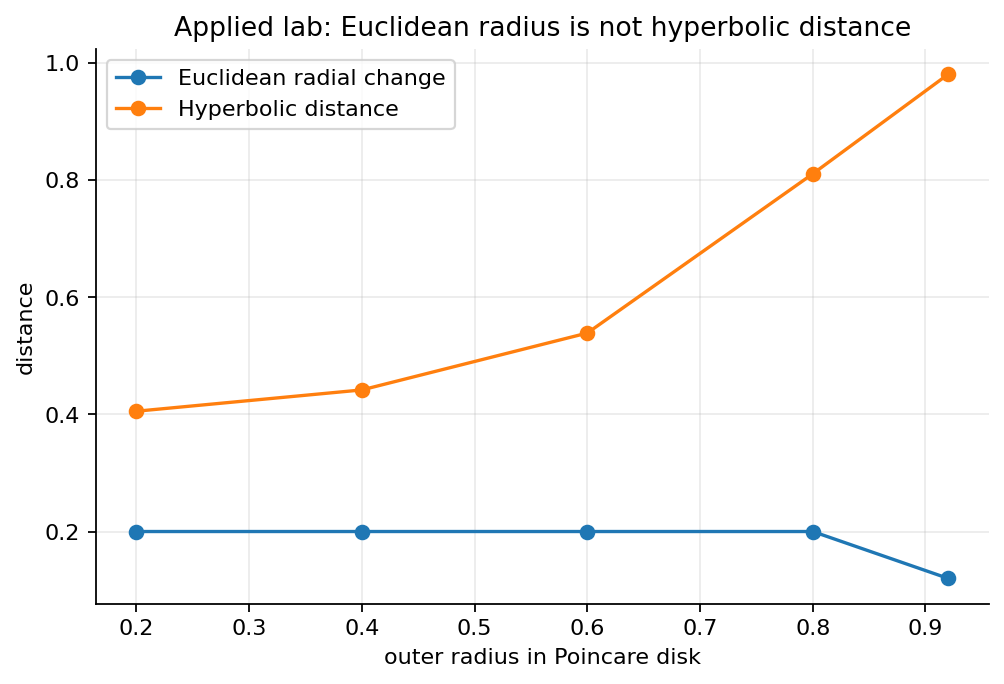

,r1,r2,euclidean_delta,hyperbolic_distance
0,0.0,0.20,0.20,0.405465
1,0.2,0.40,0.20,0.441833
2,0.4,0.60,0.20,0.538997
3,0.6,0.80,0.20,0.810930
4,0.8,0.92,0.12,0.980829


In [8]:
def poincare_radial_distance(r1, r2):
    return abs(math.log((1 + r2) * (1 - r1) / ((1 - r2) * (1 + r1))))
rows = []
for r1, r2 in [(0.0,.2), (.2,.4), (.4,.6), (.6,.8), (.8,.92)]:
    rows.append({'r1': r1, 'r2': r2, 'euclidean_delta': r2-r1, 'hyperbolic_distance': poincare_radial_distance(r1, r2)})
lab_df = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(7.2, 4.5))
ax.plot(lab_df['r2'], lab_df['euclidean_delta'], marker='o', label='Euclidean radial change')
ax.plot(lab_df['r2'], lab_df['hyperbolic_distance'], marker='o', label='Hyperbolic distance')
ax.set_xlabel('outer radius in Poincare disk'); ax.set_ylabel('distance')
ax.set_title('Applied lab: Euclidean radius is not hyperbolic distance')
ax.legend(); ax.grid(alpha=.25)
lab_png = remember(save_matplotlib(fig, FIG / 'applied-lab-poincare-distance-scale.png'))
plt.close(fig)
lab_csv = remember(save_csv(rows, TABLE / 'applied-lab-poincare-distance-scale.csv'))
lab_json = remember(save_json({'rows': rows, 'checks': {'hyperbolic_distance_increases_near_boundary': rows[-1]['hyperbolic_distance'] > rows[0]['hyperbolic_distance']}}, CHECK / 'applied-lab-poincare-distance-scale.json'))
assert rows[-1]['hyperbolic_distance'] > rows[0]['hyperbolic_distance']
display_artifact(lab_png)
lab_df


## Source-Coverage Note

This chapter uses the source span as a progression from physical intuition to algebraic models. The negatively curved surface cell explains why embedded surfaces are only local guides. The disk and half-plane cell covers inversive/conformal models and the metric scale that makes boundary-near Euclidean segments hyperbolically large. The projection cell compares hyperboloid, Klein, and Poincare coordinates so the learner can see which model preserves lines, angles, or distance formulas. The computation cell records the Minkowski inner-product identity and a triangle-law residual, while the Hopf-flow cell marks the transition from hyperbolic space to the geometry of the three-sphere. Together these checks cover the chapter's main route without copying its figures.


## Final Sanity Checks

The final cell verifies the artifact ledger, the core model identities, and nonblank PNG generation. The purpose is not to certify the whole theory of hyperbolic manifolds; it is to make sure the notebook's finite inspections honestly support the chapter route.


In [9]:
from PIL import Image, ImageStat
chapter_completion_note = 'TDGT Chapter 2 final_sanity: hyperbolic model comparison and S3 Hopf-flow checks.'
assert_artifacts(ARTIFACTS, min_bytes=80)
png_stats = []
for png in sorted(FIG.glob('*.png')):
    with Image.open(png) as img:
        stat = ImageStat.Stat(img.convert('RGB'))
        png_stats.append({'path': png.relative_to(BOOK_ROOT).as_posix(), 'width': img.width, 'height': img.height, 'stddev': max(stat.stddev)})
assert png_stats and all(item['width'] >= 300 and item['height'] >= 250 and item['stddev'] > 1 for item in png_stats)
final_sanity = {
    'unit': UNIT_KEY,
    'source_span': 'printed pages 43-108',
    'artifact_count': len(ARTIFACTS),
    'png_count_in_artifact_tree': len(png_stats),
    'checks': {
        'pseudosphere_radius_decreases': all(radius_ledger[i]['radius'] > radius_ledger[i+1]['radius'] for i in range(len(radius_ledger)-1)),
        'poincare_geodesics_orthogonal': max(residuals) < 1e-12,
        'projection_domains_valid': inside_klein and inside_poincare,
        'hyperboloid_distance_checks': all(checks.values()),
        'poincare_lab_detects_boundary_scale': rows[-1]['hyperbolic_distance'] > rows[0]['hyperbolic_distance'],
    },
    'png_stats': png_stats,
}
final_path = remember(save_json(final_sanity, CHECK / 'final-sanity.json'))
assert_artifacts([final_path], min_bytes=300)
display(Markdown(f"final_sanity passed for **{UNIT_TITLE}** with {len(ARTIFACTS)} tracked artifacts."))
final_sanity


final_sanity passed for **Hyperbolic Geometry And Its Friends** with 14 tracked artifacts.

{'unit': 'chapter-02-hyperbolic-geometry-and-its-friends',
 'source_span': 'printed pages 43-108',
 'artifact_count': 13,
 'png_count_in_artifact_tree': 3,
 'checks': {'pseudosphere_radius_decreases': True,
  'poincare_geodesics_orthogonal': True,
  'projection_domains_valid': True,
  'hyperboloid_distance_checks': True,
  'poincare_lab_detects_boundary_scale': True},
 'png_stats': [{'path': 'artifacts/chapter-02-hyperbolic-geometry-and-its-friends/figures/applied-lab-poincare-distance-scale.png',
   'width': 1004,
   'height': 684,
   'stddev': 36.34688828878898},
  {'path': 'artifacts/chapter-02-hyperbolic-geometry-and-its-friends/figures/hyperboloid-klein-poincare-projections.png',
   'width': 1271,
   'height': 628,
   'stddev': 46.91151504230887},
  {'path': 'artifacts/chapter-02-hyperbolic-geometry-and-its-friends/figures/poincare-half-plane-models.png',
   'width': 1333,
   'height': 764,
   'stddev': 38.61608695742268}]}

## Takeaways

- Hyperbolic geometry is best learned by moving among models and watching which quantities survive the move.
- The Poincare disk is conformal; the Klein disk straightens geodesics; the hyperboloid model makes distance algebraic.
- Negative curvature in Euclidean space is a local guide but not a complete global model.
- The three-sphere and Hopf flow show why Thurston treats geometry as homogeneous structure, not merely drawing in a preferred coordinate system.
